In [1]:
from mapf import *
from rcbs import *
from matplotlib import pyplot as plt
import numpy as np

(16, 16)
16.0


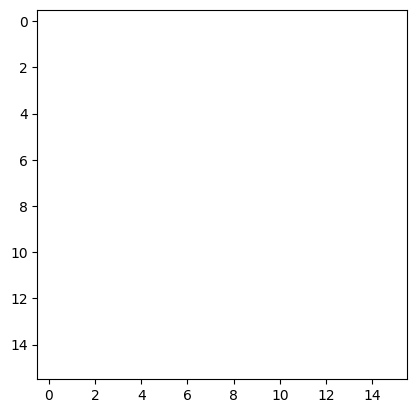

In [3]:
nrows = 16
ncols = 16
size = (nrows, ncols)
env = GridWorld(size, [])
print(size)
print(np.sqrt(size[0]*size[1]-len(env.obstacles)))
fig, ax = plt.subplots()
draw_environment(ax,env,{},{})

In [6]:
# generate a problem with some number of agents
N_agents = 64
start_pos, final_pos = random_problem(N_agents, env)
x = dict((id, PathVertex(pos, 0)) for id, pos in start_pos.items())

In [7]:
omega = 1.1 # suboptimality factor

# one action generator per agent (probably not strictly necessary)
action_generators = dict((id, GridWorldActionGenerator(env)) for id in x)

# create root node with start positions
root = ecbs.ECBSNode(x)

# create dictionary of LocationGoals from final_pos
goals = dict((id, LocationGoal(value)) for id, value in final_pos.items())

# call update_paths to run initial A* on agents, this updates the root node
ecbs.update_paths(root, action_generators, goals, list(x.keys()), omega)

# run ECBS
node, O, F = ecbs.enhanced_cbs(root, action_generators, goals, omega)

In [8]:
solution = MAPFSolution(node.paths)
print(solution.verify())
print(solution.sum_of_path_lengths())

[]
795


28


MovieWriter ffmpeg unavailable; using Pillow instead.


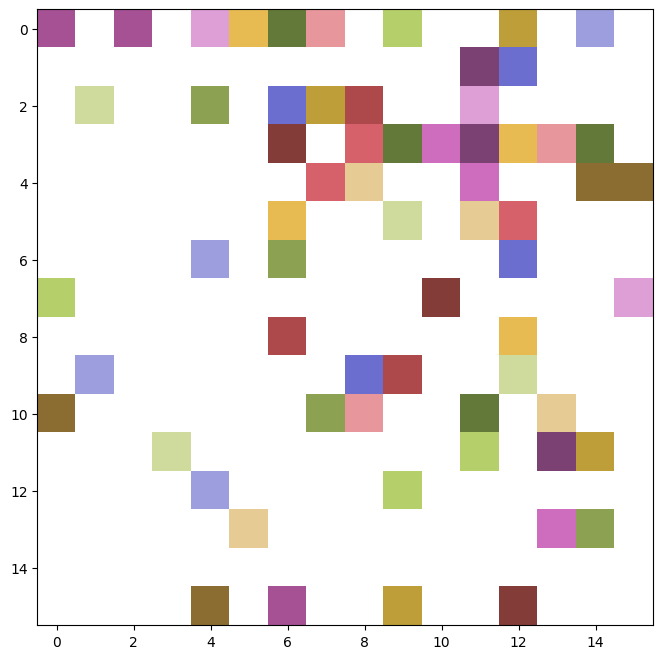

In [9]:
MAPFAnimation(env, solution).animate().save('foo.gif')